# Побудова моделі


<h2>Мета</h2>

Ознайомитись з різновидами регресійних моделей. Після завершення цієї лабораторної роботи ви зможете:

* Будувати регресійні моделі кількох видів
* Оцінювати якість моделі візуально
* Оцінювати якість моделі за допомогою числових мір, без використання тестової вибірки
* Виконувати прогнозування відгуку, використовуючи побудовану модель



<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>

1. Скачати дані із файлу "clean_data2.csv" (Data2.csv з виправленими помилками та заповненими пропусками). Записати дані у dataframe. В попередній роботі ви визначили ознаки, що можуть бути предикторами для 'CO2 emission'. Побудуйте моделі лінійної регресії для кожного з цих предикторів.
2. Побудуйте модель множинної лінійної регресії для всіх доречних предикторів разом.
3. Побудуйте кілька поліноміальних моделей другого порядку.
4. Побудуйте візуалізації для оцінки всіх моделей.
5. Порахуйте значення R^2 та MSE для оцінки якості кожної моделі. Оберіть найкращу модель.


<a name="task1"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Скачати дані із файлу <a href="https://drive.google.com/file/d/1wSj5SKRPKOjNPP2cyqaNpxRCinKEmJkO/view?usp=drive_link" target="_blank">'clean_data2.csv'</a> (Data2.csv з виправленими помилками та заповненими пропусками). Записати дані у dataframe. </p><p>В попередній роботі ви визначили ознаки, що можуть бути предикторами для 'CO2 emission'. Побудуйте моделі лінійної регресії для кожного з цих предикторів.</p>
</div>

Зчитую дані з файлу у датафрейм


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "clean_data2.csv"
df = pd.read_csv(path)
df.head()

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225000,652860,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853000,28750,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217000,2381740,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,165114.116337,200,277.995000
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042000,470,164.427660


<p>З попередньої роботи знаємо, що хорошими показниками для 'CO2 emission' можуть бути:</p>
<ul>
    <li>Population</li>
    <li>Area</li>
</ul>
Розробимо моделі, використовуючи ці ознаки як змінні-предиктори.

<p>Створюю об’єкт лінійної регресії та навчаю першу модель</p>


In [74]:
from sklearn.linear_model import LinearRegression

lm1 = LinearRegression()
lm1.fit(df[['Population']], df[['CO2 emission']])

LinearRegression()

Знаходжу коефіцієнти моделі


In [76]:
lm1.coef_

array([[0.00483347]])

In [78]:
lm1.intercept_

array([-782.86425154])

Отримали кінцеву лінійну модель зі структурою:
$$
Yhat1 = a + b  X
$$

Підставляючи фактичні значення, маємо:

CO2 emission = -782.86 + 0.0048 * Population

Створюю об’єкт лінійної регресії та навчаю другу модель


In [80]:
lm2 = LinearRegression()
lm2.fit(df[['Area']], df[['CO2 emission']])

LinearRegression()

Знаходжу коефіцієнти моделі


In [82]:
lm2.coef_

array([[0.259485]])

In [84]:
lm2.intercept_

array([4533.35819511])

Отримали кінцеву лінійну модель зі структурою:
$$
Yhat2 = a + b  X
$$

Підставляючи фактичні значення, маємо:


CO2 emission = 4533.36 + 0.26 * Area

<a name="task2"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Побудуйте модель множинної лінійної регресії для всіх доречних предикторів разом.</p>
</div>

Створюю об’єкт лінійної регресії та навчаю множинну лінійну модель із структурою
$$
Yhat3 = a + b_1 X_1 + b_2 X_2
$$

In [166]:
lm3 = LinearRegression()
lm3.fit(df[['Population', 'Area']], df[['CO2 emission']])

LinearRegression()

Знаходжу коефіцієнти моделі


In [88]:
lm3.coef_

array([[0.00407087, 0.12369062]])

In [90]:
lm3.intercept_

array([-51153.70055281])

Підставляючи фактичні значення, маємо:

CO2 emission = -51153.7 + 0.004 * Population + 0.124 * Area

<a name="task3"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Побудуйте кілька поліноміальних моделей другого порядку.</p>
</div>

Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat4 = a + b_1 X_1 + b_2 X_1^2  
$$

Знаходжу коефіцієнти моделі


In [92]:
f4 = np.polyfit(df['Population'], df['CO2 emission'], 2)
p4 = np.poly1d(f4)
print(p4)

            2
-3.004e-13 x + 0.00521 x - 7948


Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat5 = a + b_1 X_2 + b_2 X_2^2
$$

Знаходжу коефіцієнти моделі


In [94]:
f5 = np.polyfit(df['Area'], df['CO2 emission'], 2)
p5 = np.poly1d(f5)
print(p5)

            2
-1.484e-08 x + 0.436 x - 4.963e+04


Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat6 = a + b_1 X_1 + b_2 X_2 + b_3 X_1 X_2 + b_4 X_1^2 + b_5 X_2^2
$$

Знаходжу коефіцієнти моделі


In [190]:
from sklearn.preprocessing import PolynomialFeatures

pr=PolynomialFeatures(degree=2)
Z_pr=pr.fit_transform(df[['Population', 'Area']])
lm3.fit(Z_pr,df['CO2 emission'])
coef = lm3.coef_
coef

array([ 0.00000000e+00,  2.26971621e-03,  2.19204309e-02, -3.11058456e-12,
        1.02011340e-09, -4.10609834e-09])

<a name="task4"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудуйте візуалізації для оцінки всіх моделей.</p>
</div>

Для простої лінійної регресії чудовим способом візуалізації відповідності моделі є використання графіків регресії. Цей графік покаже комбінацію розсіяних точок даних (діаграма розсіювання, scatterplot) та підігнану лінію лінійної регресії, що проходить через дані.

Таким способом візуалізую перші моделі.


In [100]:
import seaborn as sns
%matplotlib inline

Візуалізуємо 'Population' як потенційний предиктор зміни ціни:

(0.0, 1447597695.15)

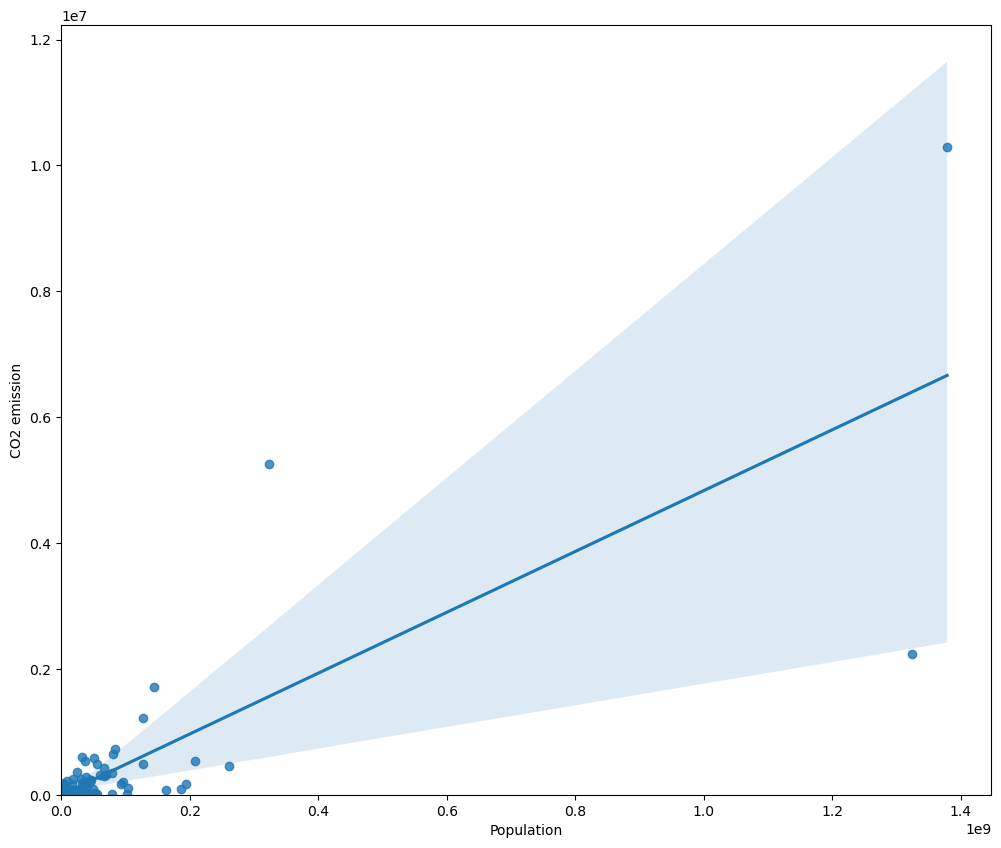

In [102]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.regplot(x='Population', y='CO2 emission', data=df)
plt.ylim(0,)
plt.xlim(0,)

Візуалізуємо 'Area' як потенційний предиктор зміни ціни:

(0.0, 17953162.4)

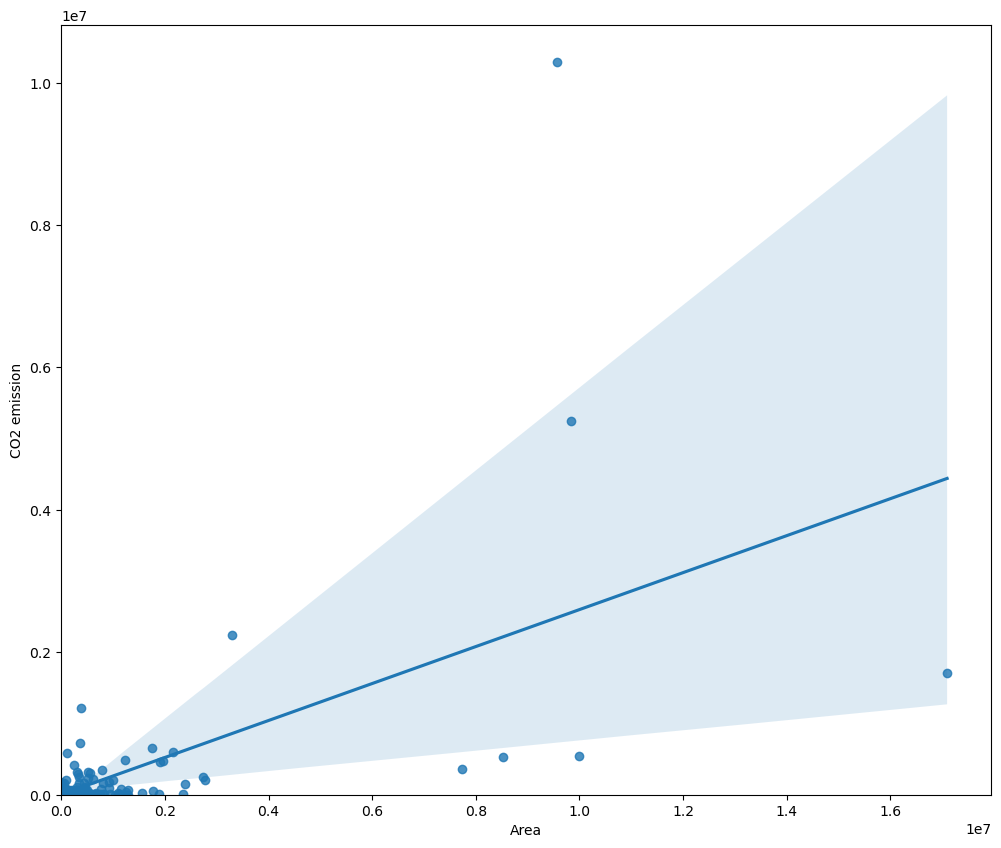

In [104]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.regplot(x='Area', y='CO2 emission', data=df)
plt.ylim(0,)
plt.xlim(0,)

In [106]:
df[['Population','Area','CO2 emission']].corr()

,Population,Area,CO2 emission
Population,1.000000,0.453500,0.802232
Area,0.453500,1.000000,0.585512
CO2 emission,0.802232,0.585512,1.000000


З діаграм бачимо, що кут нахилу регресії є позитивним, тобто CO2 emission позитивно корелює і з Population, і з Area. Враховуючи метод .corr(), кореляція з Population є більшою, ніж з Area.

Для візуалізації дисперсії даних використаю діаграми залишків.


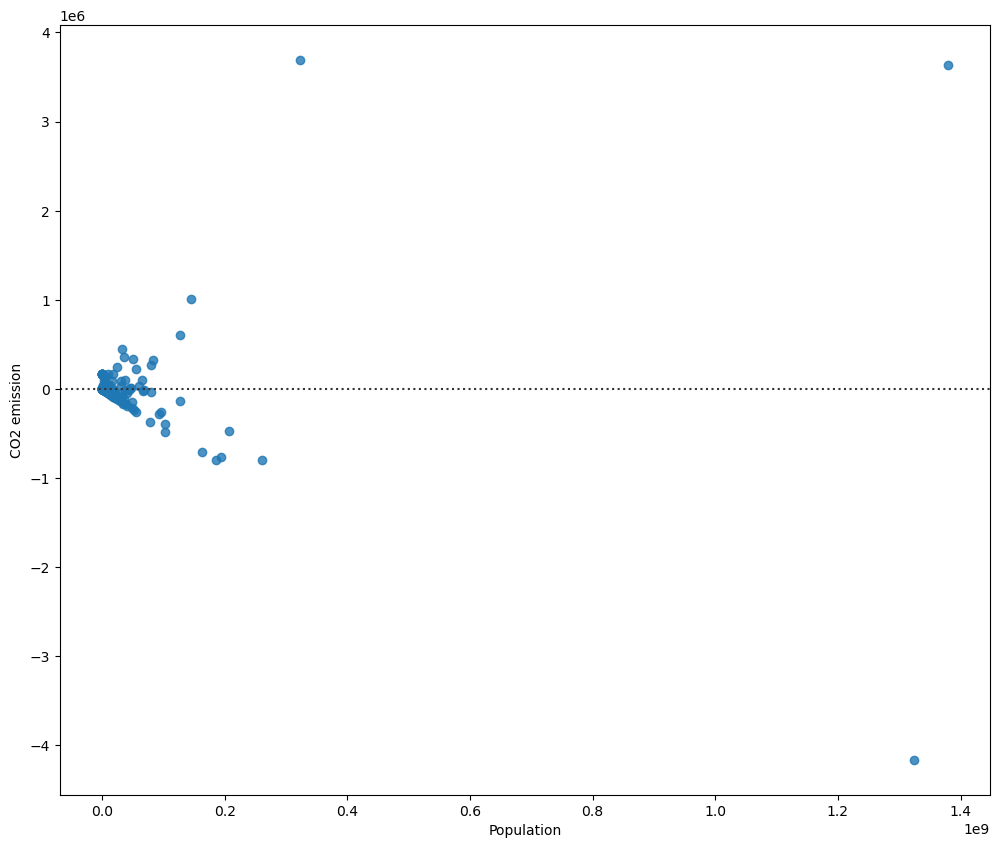

In [108]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.residplot(x=df['Population'], y=df['CO2 emission'])
plt.show()

На діаграмі бачимо, що залишки розподілені випадковим чином, тобто для даних підходить лінійна модель.

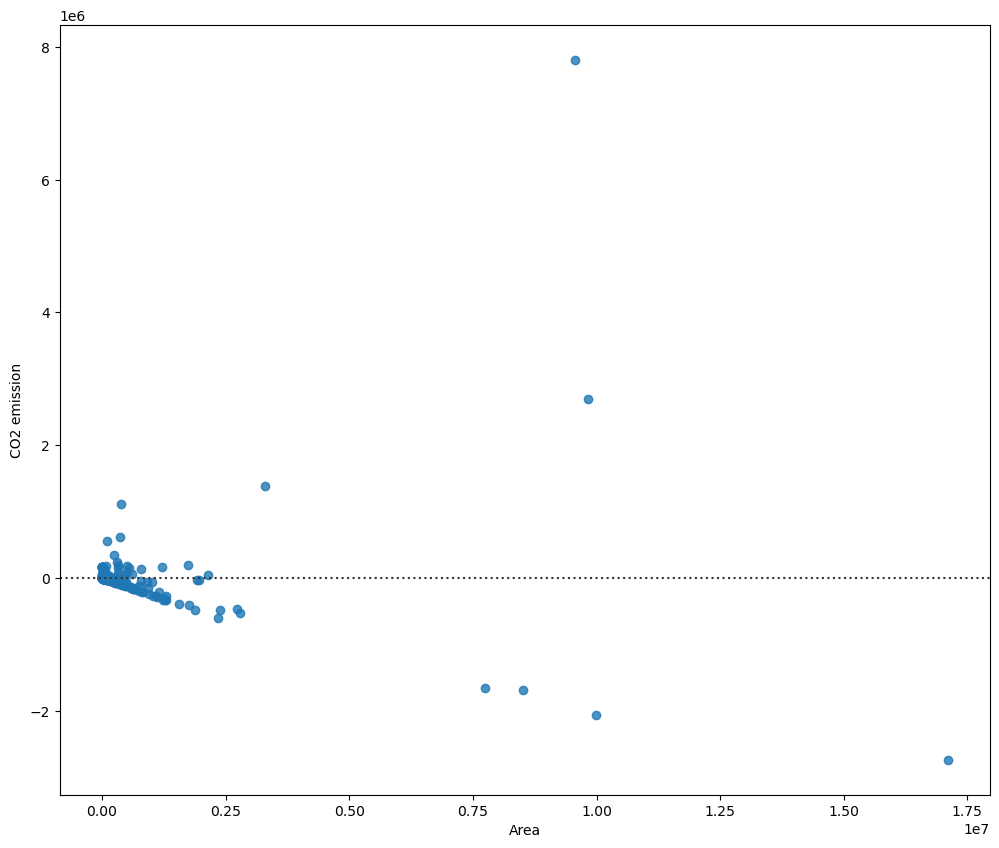

In [110]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.residplot(x=df['Area'], y=df['CO2 emission'])
plt.show()

На діаграмі бачимо, що залишки розподілені випадковим чином, тобто для даних підходить лінійна модель.

Для візуалізації моделі множинної лінійної регресії використаю діаграму розподілу.


/var/folders/zh/n_3dg3js4wxglp5cp444j3pr0000gn/T/ipykernel_17539/1673001095.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['CO2 emission'], hist=False, color="r", label="Actual Value")
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/zh/n_3dg3js4wxglp5cp444j3pr0000gn/T/ipykernel_17539/1673001095.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.


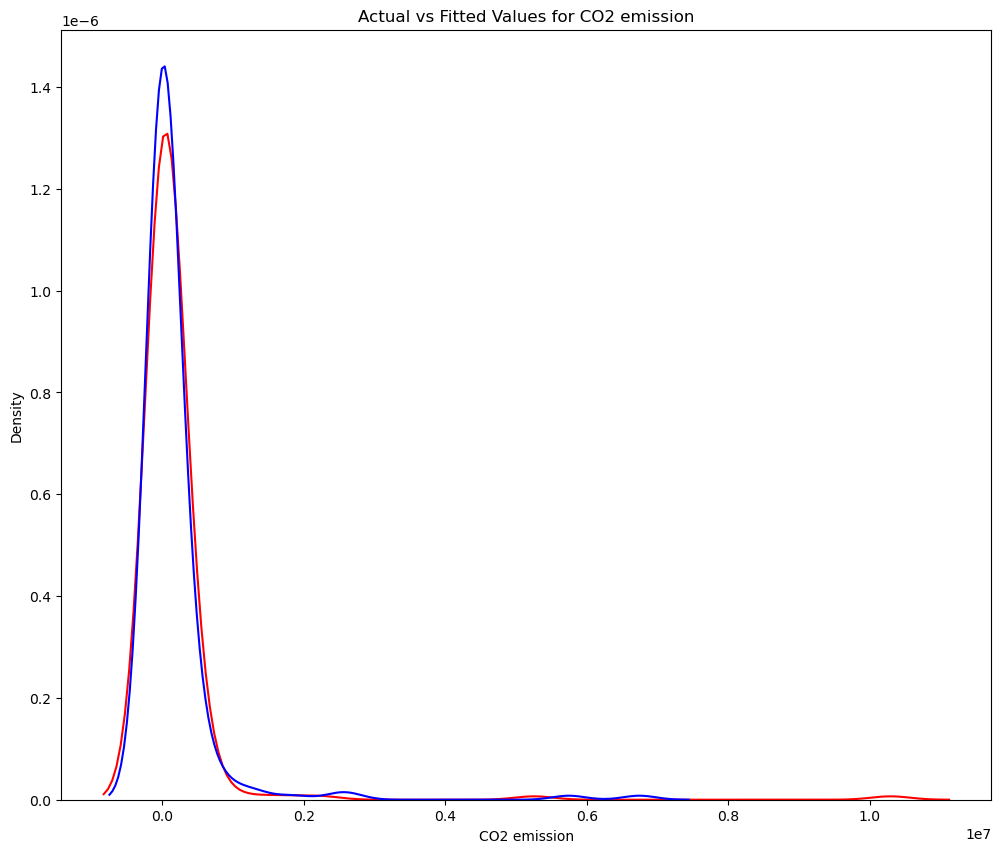

In [121]:
Y_hat = lm3.predict(df[['Population', 'Area']])
plt.figure(figsize=(width, height))


ax1 = sns.distplot(df['CO2 emission'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_hat, hist=False, color="b", label="Fitted Values" , ax=ax1)


plt.title("Actual vs Fitted Values for CO2 emission")
plt.xlabel("CO2 emission")

plt.show()
plt.close()

Бачимо, що підігнані значення досить близькі до фактичних значень, оскільки два розподіли трохи накладаються.

Для візуалізації поліноміальних моделей з одним предиктором використаю функцію <code>poly1d</code>


In [56]:
def PlotPolly(model, independent_variable, dependent_variable, Name):
    min_v = min(independent_variable)
    max_v = max(independent_variable)
    x_new = np.linspace(min_v, max_v, 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variable, '.', x_new, y_new, '-')
    plt.title("Polynomial Fit with CO2 emission")
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel("CO2 emission")

    plt.show()
    plt.close()

            2
-3.004e-13 x + 0.00521 x - 7948


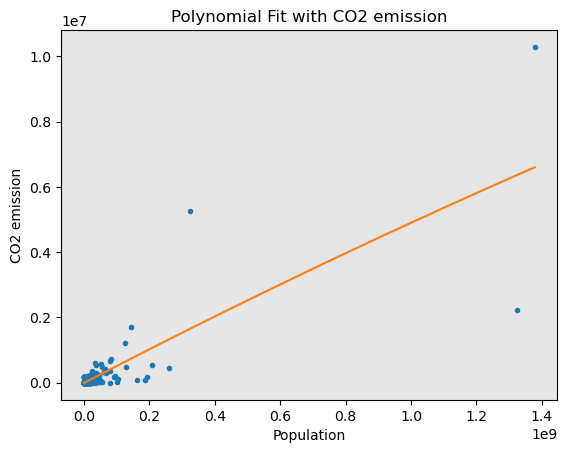

In [59]:
f4 = np.polyfit(df['Population'], df['CO2 emission'], 2)
p4 = np.poly1d(f4)
print(p4)
PlotPolly(p4, df['Population'], df['CO2 emission'], 'Population')

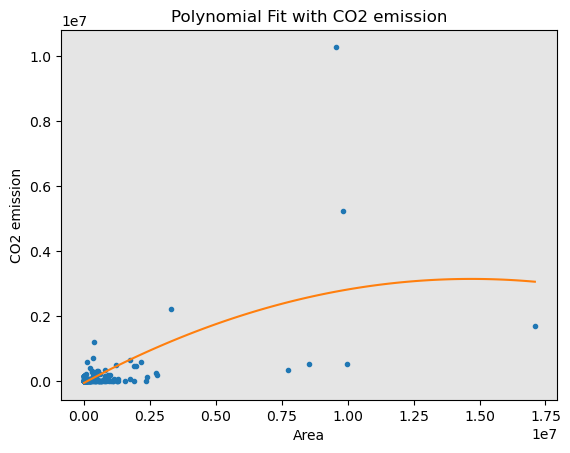

In [64]:
PlotPolly(p5, df['Area'], df['CO2 emission'], 'Area')

Для візуалізації поліноміальних моделей з кількома предикторами використаю діаграму розподілу або діаграму залишків


Діграма розподілу:

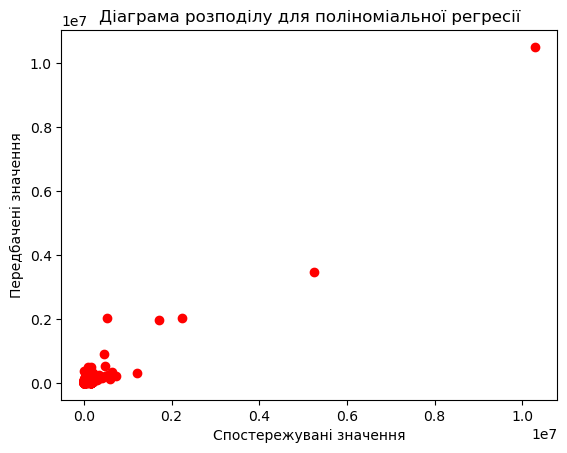

In [131]:
plt.scatter(df['CO2 emission'], lm3.predict(Z_pr), color='red') 
plt.xlabel("Спостережувані значення") 
plt.ylabel("Передбачені значення")
plt.title("Діаграма розподілу для поліноміальної регресії") 
plt.show()

Діаграма залишків:

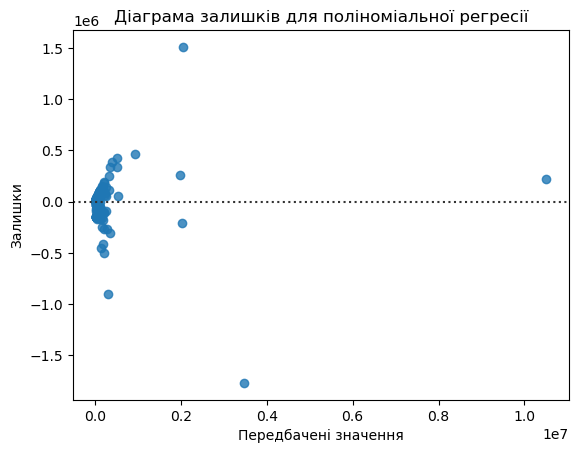

In [142]:
sns.residplot(x=lm3.predict(Z_pr), y=lm3.predict(Z_pr) - df['CO2 emission']) 
plt.xlabel("Передбачені значення")
plt.ylabel("Залишки")
plt.title("Діаграма залишків для поліноміальної регресії") 
plt.show()

<a name="task5"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Порахуйте значення R^2 та MSE для оцінки якості кожної моделі. Оберіть найкращу модель.</p>
</div>

Значення R^2 отримую безпосередньо з моделі <code>.score(X, Y)</code>, а для розрахунку MSE спочатку формую прогнозовані значення <code>.predict(X)</code> і порівнюю їх з фактичними


Модель 1:
$$
Yhat1 = a + b  X
$$


In [156]:
from sklearn.metrics import mean_squared_error

In [146]:
print('The R-square value is: ', lm1.score(df[['Population']], df['CO2 emission']))

The R-square value is:  0.6435755233131817


In [158]:
print('The MSE is: ', mean_squared_error(df['CO2 emission'], lm1.predict(df[['Population']])))

The MSE is:  232801816739.9179


Модель 2:
$$
Yhat2 = a + b  X
$$

In [160]:
print('The R-square value is: ', lm2.score(df[['Area']], df['CO2 emission']))

The R-square value is:  0.34282421100737415


In [162]:
print('The MSE is: ', mean_squared_error(df['CO2 emission'], lm2.predict(df[['Area']])))

The MSE is:  429240211045.8941


Модель 3:
$$
Yhat3 = a + b_1 X_1 + b_2 X_2
$$

In [168]:
print('The R-square value is: ', lm3.score(df[['Population', 'Area']], df['CO2 emission']))

The R-square value is:  0.705452018011884


In [174]:
print('The MSE is: ', mean_squared_error(df['CO2 emission'], lm3.predict(df[['Population', 'Area']])))

The MSE is:  192386633940.86154


Модель 4:
$$
Yhat4 = a + b_1 X_1 + b_2 X_1^2  
$$

In [178]:
from sklearn.metrics import r2_score

print('The R-square value is: ', r2_score(df['CO2 emission'], p4(df['Population'])))

The R-square value is:  0.643890609154327


In [180]:
print('The MSE is: ', mean_squared_error(df['CO2 emission'], p4(df['Population'])))

The MSE is:  232596015620.61905


Модель 5:
$$
Yhat5 = a + b_1 X_2 + b_2 X_2^2
$$

In [182]:
print('The R-square value is: ', r2_score(df['CO2 emission'], p5(df['Area'])))

The R-square value is:  0.3698523918567883


In [184]:
print('The MSE is: ', mean_squared_error(df['CO2 emission'], p5(df['Area'])))

The MSE is:  411586514354.21747


Модель 6:
$$
Yhat6 = a + b_1 X_1 + b_2 X_2 + b_3 X_1 X_2 + b_4 X_1^2 + b_5 X_2^2
$$

In [192]:
print('The R-square value is: ', r2_score(df['CO2 emission'], lm3.predict(Z_pr)))

The R-square value is:  0.9359013231949563


In [194]:
print('The MSE is: ', mean_squared_error(df['CO2 emission'], lm3.predict(Z_pr)))

The MSE is:  41866620804.35871


<h4>Висновок</h4>

<p>Порівнюючи всі моделі, роблю висновок, що <b>модель з кількома предикторами є найкращою моделлю</b> для прогнозування 'CO2 emission' на основі нашого набору даних. </p>


<a name="task6"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Побудуйте та оцініть кілька поліноміальних моделей різних порядків.</p>
</div>

1. Побудуйте кілька поліноміальних моделей різних порядків.
2. Побудуйте візуалізації для оцінки всіх моделей.
3. Порахуйте значення R^2 та MSE для оцінки якості кожної моделі. Оберіть найкращу модель.


            2
-1.484e-08 x + 0.436 x - 4.963e+04


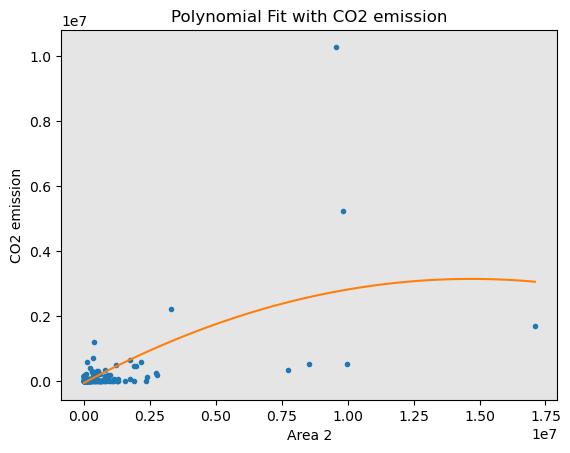

In [207]:
fa_2 = np.polyfit(df['Area'], df['CO2 emission'], 2)
pa_2 = np.poly1d(fa_2)
print(pa_2)
PlotPolly(pa_2, df['Area'], df['CO2 emission'], 'Area 2')

In [209]:
print('The R-square value is: ', r2_score(df['CO2 emission'], pa_2(df['Area'])))
print('The MSE is: ', mean_squared_error(df['CO2 emission'], pa_2(df['Area'])))

The R-square value is:  0.3698523918567883
The MSE is:  411586514354.21747


           4             3             2
-1.67e-21 x + 4.215e-14 x - 2.531e-07 x + 0.4529 x + 1875


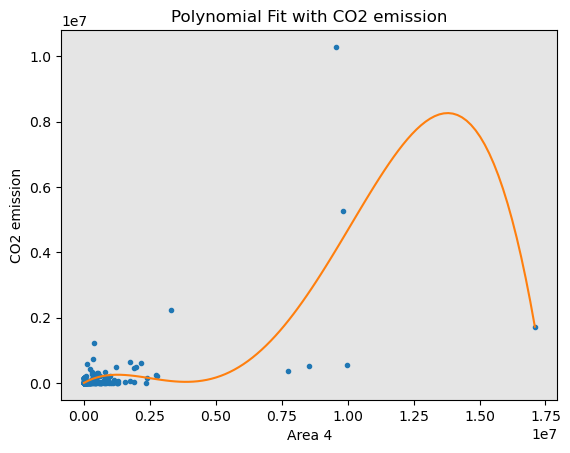

In [211]:
fa_4 = np.polyfit(df['Area'], df['CO2 emission'], 4)
pa_4 = np.poly1d(fa_4)
print(pa_4)
PlotPolly(pa_4, df['Area'], df['CO2 emission'], 'Area 4')

In [213]:
print('The R-square value is: ', r2_score(df['CO2 emission'], pa_4(df['Area'])))
print('The MSE is: ', mean_squared_error(df['CO2 emission'], pa_4(df['Area'])))

The R-square value is:  0.4873119726056263
The MSE is:  334866744584.12445


            5             4             3             2
-3.748e-28 x + 1.095e-20 x - 9.237e-14 x + 2.625e-07 x - 0.07751 x + 4.931e+04


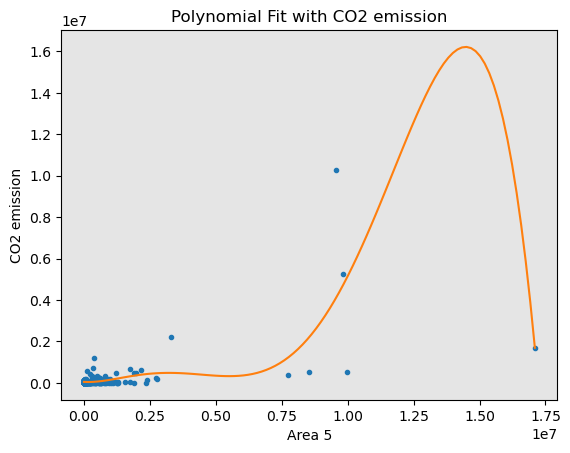

In [217]:
fa_5 = np.polyfit(df['Area'], df['CO2 emission'], 5)
pa_5 = np.poly1d(fa_5)
print(pa_5)
PlotPolly(pa_5, df['Area'], df['CO2 emission'], 'Area 5')

In [219]:
print('The R-square value is: ', r2_score(df['CO2 emission'], pa_5(df['Area'])))
print('The MSE is: ', mean_squared_error(df['CO2 emission'], pa_5(df['Area'])))

The R-square value is:  0.5046575981616349
The MSE is:  323537294992.26227


           6             5             4             3             2
2.571e-34 x - 1.023e-26 x + 1.409e-19 x - 7.967e-13 x + 1.678e-06 x - 0.9022 x + 9.531e+04


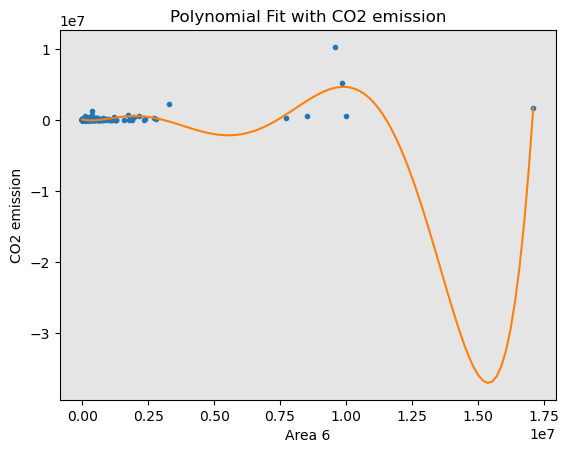

In [221]:
fa_6 = np.polyfit(df['Area'], df['CO2 emission'], 6)
pa_6 = np.poly1d(fa_6)
print(pa_6)
PlotPolly(pa_6, df['Area'], df['CO2 emission'], 'Area 6')

In [223]:
print('The R-square value is: ', r2_score(df['CO2 emission'], pa_6(df['Area'])))
print('The MSE is: ', mean_squared_error(df['CO2 emission'], pa_6(df['Area'])))

The R-square value is:  0.5213547123144421
The MSE is:  312631426390.81146


           8             7            6             5             4
1.262e-46 x - 5.892e-39 x + 1.05e-31 x - 9.096e-25 x + 4.001e-18 x
              3             2
 - 8.468e-12 x + 7.669e-06 x - 2.12 x + 1.034e+05


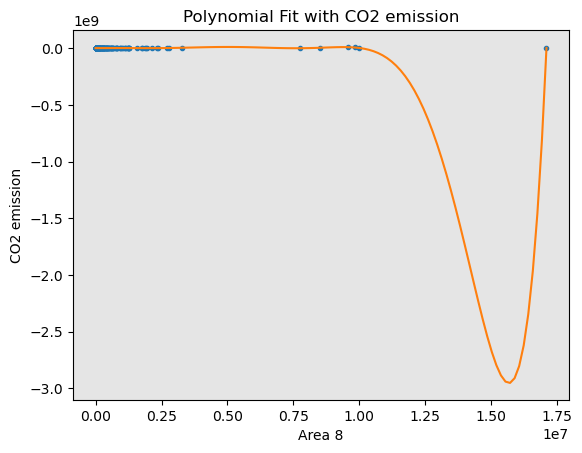

In [225]:
fa_8 = np.polyfit(df['Area'], df['CO2 emission'], 8)
pa_8 = np.poly1d(fa_8)
print(pa_8)
PlotPolly(pa_8, df['Area'], df['CO2 emission'], 'Area 8')

In [227]:
print('The R-square value is: ', r2_score(df['CO2 emission'], pa_8(df['Area'])))
print('The MSE is: ', mean_squared_error(df['CO2 emission'], pa_8(df['Area'])))

The R-square value is:  0.8361012669089134
The MSE is:  107051915120.02293


           10             9           8             7             6
-2.85e-61 x  + 5.525e-53 x - 2.3e-45 x + 4.159e-38 x - 3.889e-31 x
              5            4           3             2
 + 1.971e-24 x - 5.35e-18 x + 7.5e-12 x - 4.933e-06 x + 1.271 x + 7475


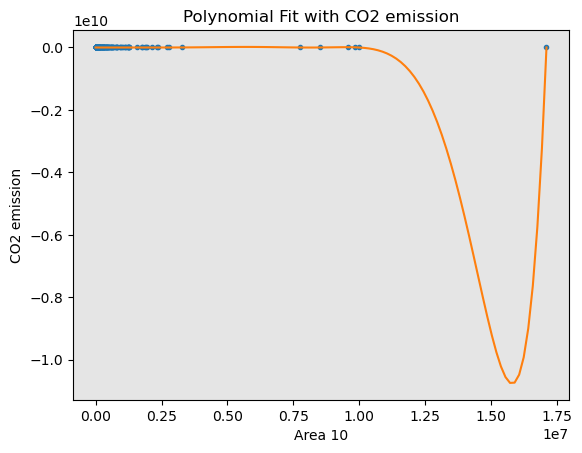

In [229]:
fa_10 = np.polyfit(df['Area'], df['CO2 emission'], 10)
pa_10 = np.poly1d(fa_10)
print(pa_10)
PlotPolly(pa_10, df['Area'], df['CO2 emission'], 'Area 10')

In [231]:
print('The R-square value is: ', r2_score(df['CO2 emission'], pa_10(df['Area'])))
print('The MSE is: ', mean_squared_error(df['CO2 emission'], pa_10(df['Area'])))

The R-square value is:  0.9648976018673499
The MSE is:  22927443516.706932


Найкращою моделлю є поліноміальна модель 10-го порядку, оскільки вона має найменше MSE і найбільше R-square.

<h2>Виконав студент групи ІП-23<br>  Матвієнко Дарʼя</h2>